**Breast Cancer prediction using ANN**


In [7]:
# importing required library for loading dataset
import sklearn
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

In [8]:
# read the dataset
full_df = pd.read_csv("C:/Users/oyelola Ibrahim/Desktop/breast-cancer.csv")
full_df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [9]:
full_df.drop(["id"], inplace=True, axis=1)

In [18]:
full_df.tail(10)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
559,B,11.51,23.93,74.52,403.5,0.09261,0.10210,0.11120,0.04105,0.1388,...,12.480,37.16,82.28,474.2,0.12980,0.25170,0.3630,0.09653,0.2112,0.08732
560,B,14.05,27.15,91.38,600.4,0.09929,0.11260,0.04462,0.04304,0.1537,...,15.300,33.17,100.20,706.7,0.12410,0.22640,0.1326,0.10480,0.2250,0.08321
561,B,11.20,29.37,70.67,386.0,0.07449,0.03558,0.00000,0.00000,0.1060,...,11.920,38.30,75.19,439.6,0.09267,0.05494,0.0000,0.00000,0.1566,0.05905
562,M,15.22,30.62,103.40,716.9,0.10480,0.20870,0.25500,0.09429,0.2128,...,17.520,42.79,128.70,915.0,0.14170,0.79170,1.1700,0.23560,0.4089,0.14090
563,M,20.92,25.09,143.00,1347.0,0.10990,0.22360,0.31740,0.14740,0.2149,...,24.290,29.41,179.10,1819.0,0.14070,0.41860,0.6599,0.25420,0.2929,0.09873
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.22160,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.16280,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.14180,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.26500,0.4087,0.12400
568,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.00000,0.2871,0.07039


In [23]:
# Removing "Target" column from the dataset
X_train = full_df.drop("diagnosis", inplace=False, axis=1)
y_train = full_df["diagnosis"]

y_train = y_train.replace({"M":1, "B":0})

#To rearrange the data we use reset
X_train = X_train.reset_index(drop=True) 
y_train = y_train.reset_index(drop=True)

#converting numpy arrays with float
X_train = np.array(X_train, dtype=float) #converting numpy arrays with float
y_train = np.array(y_train, dtype=float)

#reshaping for matrix multiplication possible
y_train = np.array(y_train).reshape(-1,1) 

In [24]:
# defining loss function
def binary_crossentropy(y, yhat): 
    if y == 0:
        return -np.log(1.0 - yhat)
    
    if y == 1:
        return -np.log(yhat)

y = 0
yhat = 0.05

print(f'loss function: {binary_crossentropy(y, yhat)}')

loss function: 0.05129329438755058


In [25]:
# define class Perceptron
# defining the forward propagation layer
# defining the backward prpagation layer

class Perceptron:
    
    def __init__(self, x, y):
        
        self.input = np.array(x, dtype=float)   # assigning input
        self.label = np.array(y, dtype=float)   # reading label data
        self.weights = np.random.rand(x.shape[1], y.shape[1])  # randomly initialising the weights
        self.z = self.input @ self.weights
        self.yhat = self.sigmoid(self.z)  # applying activation function


    def sigmoid(self, x):
        return 1.0/(1.0 + np.exp(-x))


    def sigmoid_deriv(self, x):
        s = sigmoid(x)
        return s * (1 - s)


    def forward_prop(self):  # defining the forward propagation layer
        self.yhat = self.sigmoid(self.input @ self.weights)  # @ represents matrix multiplication
        return self.yhat


    def back_prop(self):  # defining the backward propagation layer
        gradient = self.input.T @ (-2.0 * (self.label - self.yhat) * self.sigmoid(self.yhat))  # self.input is the x value
        
        self.weights -= gradient  # to find the loss

In [28]:
# training the model
# define error parameter

simple_nn = Perceptron(X_train, y_train)
training_iterations = 1000  # assigning the no. of iteration

history = []  # storing how mean squared error changes after each iteration in this array

def mse(yhat, y):  # defining the error term i.e., Mean square error
    sum = 0.0
    for pred, label in zip(yhat, y):
        sum += (pred - label) ** 2
    return sum / len(yhat)

for i in range(training_iterations):  # training model
    simple_nn.forward_prop()
    simple_nn.back_prop()
    yhat = simple_nn.forward_prop()
    history.append(mse(yhat, simple_nn.label))

yhat = simple_nn.forward_prop()

print(f' Mean squared Error: {mse(yhat, simple_nn.label)}') #printing the error occured

 Mean squared Error: [0.08435852]


Text(0.5, 0, 'Training Iteration')

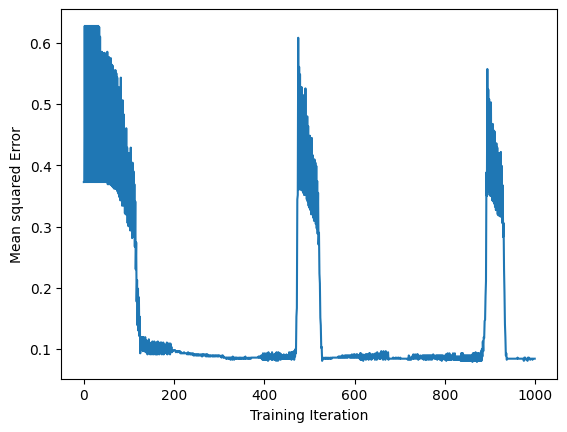

In [30]:
# plotting the graph using plt.plot 
# plot gives the change in the error term with respect to no. of iteration
plt.plot(history)
plt.ylabel('Mean squared Error')
plt.xlabel('Training Iteration')